# Function 3 Analysis - Week 4

This notebook updates the analysis for **Function 3** in Week 4. We now work with **13 datapoints**, integrating the Week 3 query that pushed to `(0.95, 0.95, 0.858)` — it came back negative and confirmed that last week’s exploratory jump did not help. We therefore pivot back toward exploitation.

**Function Description:** 
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 


## Loading and Displaying the Data

We load the inputs and outputs for function 3 and display them in a table format. Inputs remain standardised in [0,1]. The new Week 3 point at `(0.95, 0.95, 0.858)` returned **-0.0617**, i.e., another negative outcome. Combined with last week’s mediocre exploratory move, this reinforces that aggressive moves away from the known ridge are not paying off; we shift back to exploitation near the best region.


In [29]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1, Week 2, and Week 3 new points
X_new_point_week_1 = np.array([[0.403500, 0.382200, 0.489400]])
y_new_point_week_1 = np.array([-0.011750816624169894])
X_new_point_week_2 = np.array([[0.500000, 0.500000, 0.650000]])
y_new_point_week_2 = np.array([-0.09608263621357674])
X_new_point_week_3 = np.array([[0.950000, 0.950000, 0.858000]])
y_new_point_week_3 = np.array([-0.06167171939314102])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2, X_new_point_week_3])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2, y_new_point_week_3])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


df sorted by y


,x1,x2,x3,y
0,0.403500,0.382200,0.489400,-0.011751
1,0.492581,0.611593,0.340176,-0.034835
2,0.600097,0.725136,0.066089,-0.036378
3,0.220549,0.297825,0.343555,-0.046947
4,0.134622,0.219917,0.458206,-0.048008
5,0.965995,0.861120,0.566829,-0.056758
6,0.950000,0.950000,0.858000,-0.061672
7,0.242114,0.644074,0.272433,-0.087963
8,0.170477,0.697032,0.149169,-0.094190
9,0.500000,0.500000,0.650000,-0.096083


- **New point (Week 1):** The `(~0.40, ~0.38, ~0.49)` query produced the best output yet at -0.011751.
- **New point (Week 2):** The `(0.50, 0.50, 0.65)` exploratory query came back at about -0.096 (very average), hinting that simply increasing x3 in that region does not help.
- **New point (Week 3):** The `(0.95, 0.95, 0.858)` exploratory move was also negative (**-0.0617**). Two exploratory jumps in a row underperformed, so we revert to exploitation around the existing ridge.


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, and y). This helps identify linear relationships. We note a high correlation between x1 and x2. We will see later that there is a line of high output points when x1 and x2 are similar in magnitude. 


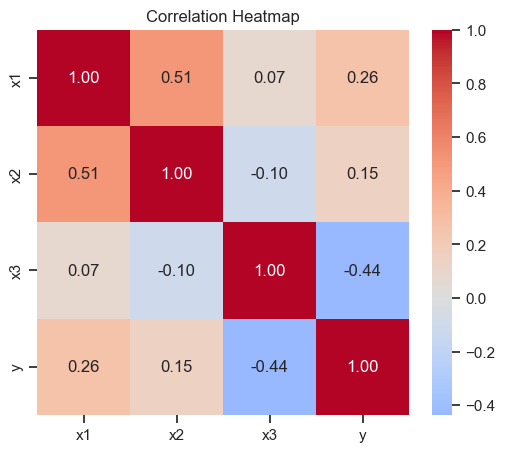

In [30]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()  

## Bayesian optimisation (expected improvement)

We use **expected improvement (EI)** and now lean back toward exploitation after two weak exploratory steps. EI converts the GP posterior (mean `μ`, std `σ`) into the expected improvement over `y_best`, balancing probability and magnitude of gain:

**EI(x) = (μ(x) − y_best − ξ) · Φ(Z) + σ(x) · φ(Z)**  
with **Z = (μ(x) − y_best − ξ) / σ(x)**, Φ the normal CDF, and φ the normal PDF.

Because the Week 2 and Week 3 exploratory jumps were negative, we **lower ξ to 0.005** to prioritise exploitation near the known ridge while still allowing modest variance-driven moves.

Workflow:
1) Fit a 3D Matern GP on `[x1, x2, x3]` (13 observed points).  
2) Evaluate EI on a dense `[0,1]^3` grid with the smaller ξ and highlight the maximiser.

`candidate_df` lists the top EI locations; rerun after adding data to refresh the ranking and plots.


In [31]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Train a GP surrogate with bounds that avoid convergence warnings
kernel = ConstantKernel(1.0, (1e-3, 10.0)) * Matern(length_scale=[0.1, 0.1, 0.1], length_scale_bounds=(0.1, 0.2), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 1e-6))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)

# Evaluate a dense grid of candidates inside the [0, 1]^3 design space
grid_size = 40  # 40^3 = 64,000 points
grid_x1 = np.linspace(0.05, 0.95, grid_size)
grid_x2 = np.linspace(0.05, 0.95, grid_size)
grid_x3 = np.linspace(0.05, 0.95, grid_size)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3)).reshape(3, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y.max()
xi = 0.001  # lower ξ to pivot back to exploitation after two weak exploratory jumps

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2", "x3"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei
next_point = candidate_df.loc[candidate_df["ei"].idxmax()]

display(candidate_df.nlargest(5, "ei"))
print(f"\nSuggested next query (EI maximiser): ({next_point.x1:.3f}, {next_point.x2:.3f}, {next_point.x3:.3f})")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a bette

,x1,x2,x3,mu,sigma,ei
14938,0.350000,0.257692,0.465385,-0.019143,0.048329,0.015374
13338,0.350000,0.234615,0.465385,-0.024258,0.053642,0.015321
14898,0.326923,0.257692,0.465385,-0.018334,0.047091,0.015238
14937,0.350000,0.257692,0.442308,-0.018874,0.047639,0.015219
13337,0.350000,0.234615,0.442308,-0.023968,0.052864,0.015137



Suggested next query (EI maximiser): (0.350, 0.258, 0.465)
Posterior mean: -0.0191, std: 0.0483, EI: 0.015374


## 3D Visualization of Recommended Point

We visualize the recommended EI maximiser in both 3D and 2D projections alongside the existing observations. This helps understand where the acquisition function suggests exploring next relative to our current data in the three-dimensional compound space. 


C:\Users\gophi\AppData\Local\Temp\ipykernel_15480\2502285868.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
C:\Users\gophi\AppData\Local\Temp\ipykernel_15480\2502285868.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")


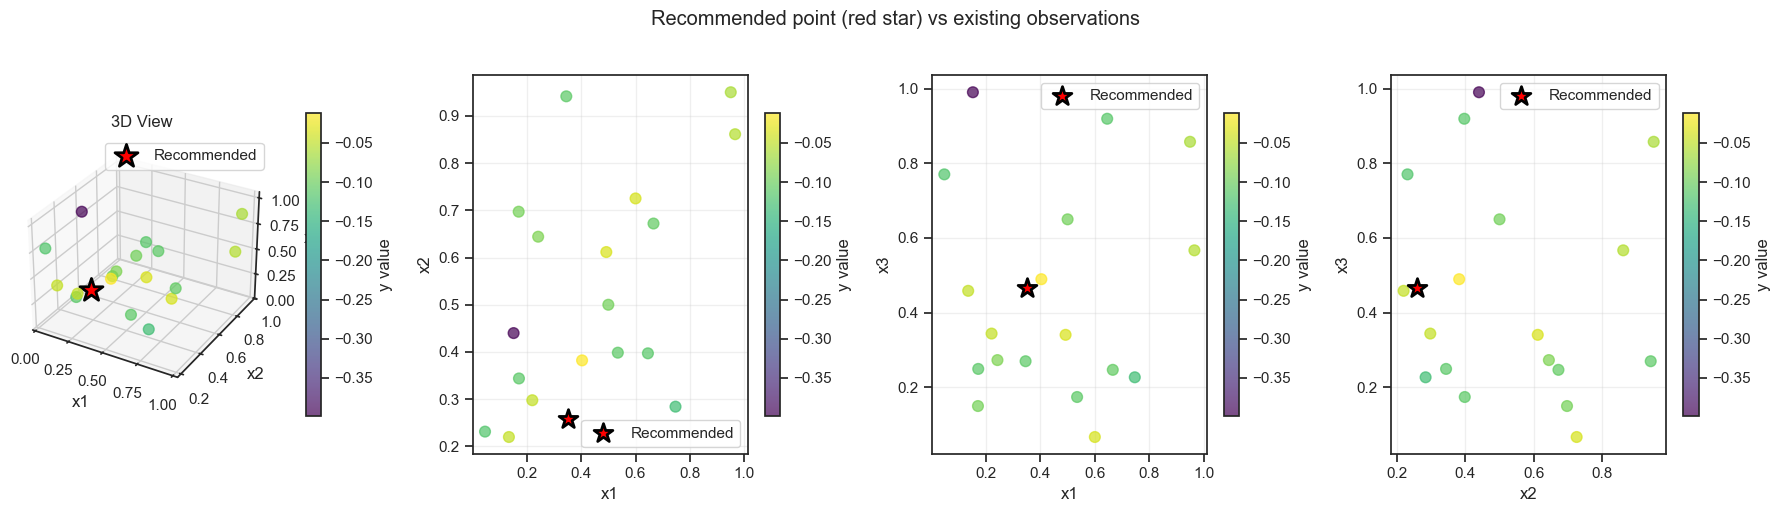

In [32]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18, 5))
ax_3d = fig.add_subplot(141, projection='3d')
scatter_3d = ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap="viridis", s=60, alpha=0.7)
ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
ax_3d.set_xlabel("x1")
ax_3d.set_ylabel("x2")
ax_3d.set_zlabel("x3")
ax_3d.legend()
ax_3d.set_title("3D View")
fig.colorbar(scatter_3d, ax=ax_3d, label="y value", shrink=0.8, pad=0.1)
axes = [fig.add_subplot(142), fig.add_subplot(143), fig.add_subplot(144)]
pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
for idx, (i, j, label_i, label_j) in enumerate(pairs):
    scatter2d = axes[idx].scatter(X[:, i], X[:, j], c=y, cmap="viridis", s=60, alpha=0.7)
    axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")
    axes[idx].set_xlabel(label_i)
    axes[idx].set_ylabel(label_j)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter2d, ax=axes[idx], label="y value", shrink=0.8)
plt.suptitle("Recommended point (red star) vs existing observations", y=1.02)
plt.tight_layout()
plt.show()


## Model parameter rationale (Week 4)
- We did some research into drug discovery to see how we can improve our hyper parameters.
- Drug discovery often shows **activity cliffs**: small composition changes can cause sharp functional jumps, so rapid changes are plausible. Measurement **noise** is also significant.
- Our previous GP used **ν = 1.5** and a relatively loose white-kernel bound, which can encourage the model to search far from the current max: it assumes sharp cliffs and that the current max might be noise-driven. We also had very wide length scales and a very large upper bound of the hyperparameter space which allowed the model to hoep for very high points in unsampled areas. 
- As a result, the model was exploring the high-(x1,x2) corner because two points there (≈`-0.0568`, `-0.0617`) were “decent.”
- We now make the GP more exploitative by setting **ν = 2.5** (smoother prior), tightening the **length-scale bounds** and **white-kernel noise bounds**, and shrinking the overall hyperparameter space. This reduces the incentive to chase distant high-variance regions and focuses search nearer the incumbent best.
--> our point for next week is (0.350, 0.258, 0.465). If that still does not work we will switch to PI instead of EI.